In [1]:

import numpy as np         #For math
import matplotlib.pyplot as plt  #For plotting graphs
import math

In [2]:
#environment
g = 9.81 #m/s^2
Earth_mass = 5.9722 * 10**24 #Mass of Earth in kilograms
Earth_radius = 6371000 #Mean radius of Earth in meters
G = 6.67430 * 10**-11 #Gravitational constant, m^2/kg^2
air_density = 1.225 #Standard air density at sea level(kg/m^3)
air_pressure = 101325 #standard air pressure at sea level(Pa)
scale_height = 8500 #constant used in equation for air thinning out(meters)
drag_coefficiant = 0.15 #Averages phases, maybe change into one that adjusts based on Mach number when I learn more python
radius = 1.83 #Radius of Falcon 9(Meters)
A = np.pi*(radius ** 2) #Cross sectional area(m^2)(10.75m^2)


#Rocket info
name = "Falcon 9 Stage 1"
flight_angle = 90
angle_rad = math.radians(flight_angle)

#Mass variables
dry_mass = 25600.0 #Mass of rocket(not including fuel) in kilograms
fuel_mass = 411000.0 #Mass of fuel for rocket in kilograms
total_mass = dry_mass + fuel_mass
weight_at_liftoff = total_mass * g


#Propulsion
THRUST = 7607000.0 #Newtons
burn_time = 162 #seconds fuel will last
twr = THRUST / weight_at_liftoff
mass_flow_rate = fuel_mass / burn_time #kgs of fuel burnt per second

#Pre-flight check
print("---ROCKET PRE-FLIGHT CHECK---")
print("Total Liftoff Mass:", total_mass, "kg")
print("Total Liftoff Weight:", weight_at_liftoff, "Newtons")
print("Thrust-to-Weight Ratio:", twr)
print("Mass Flow Rate:", mass_flow_rate, "kg/s")


---ROCKET PRE-FLIGHT CHECK---
Total Liftoff Mass: 436600.0 kg
Total Liftoff Weight: 4283046.0 Newtons
Thrust-to-Weight Ratio: 1.7760724493736466
Mass Flow Rate: 2537.037037037037 kg/s


In [3]:
#Starting rocket values(will change as the rocket travels)
time = 0.0
dt = 0.01
pos_y = 0.0
vel_y = 0.0
pos_x = 0.0
vel_x = 0.0
current_fuel = fuel_mass

print_interval = 1.0  # Only print every 1.0 second of simulation time
next_print_time = 0.0
loop_counter = 0

Time: 0.0s, Velocity: 0.1m/s, Altitude: 0.0m, Horizontal Distance: 0.0m
Time: 10.0s, Velocity: 81.4m/s, Altitude: 399.1m, Horizontal Distance: 0.0m
Time: 20.0s, Velocity: 173.9m/s, Altitude: 1666.6m, Horizontal Distance: 0.0m
Time: 30.0s, Velocity: 278.8m/s, Altitude: 3919.6m, Horizontal Distance: 0.0m
Time: 40.0s, Velocity: 397.9m/s, Altitude: 7290.7m, Horizontal Distance: 0.0m
Time: 50.0s, Velocity: 533.7m/s, Altitude: 11934.0m, Horizontal Distance: 0.0m
Time: 60.0s, Velocity: 689.8m/s, Altitude: 18033.6m, Horizontal Distance: 0.0m
Time: 70.0s, Velocity: 870.2m/s, Altitude: 25812.0m, Horizontal Distance: 0.0m
Time: 80.0s, Velocity: 1080.2m/s, Altitude: 35537.8m, Horizontal Distance: 0.0m
Time: 90.0s, Velocity: 1326.3m/s, Altitude: 47537.8m, Horizontal Distance: 0.0m
Time: 100.0s, Velocity: 1617.5m/s, Altitude: 62215.6m, Horizontal Distance: 0.0m
Time: 110.0s, Velocity: 1967.1m/s, Altitude: 80084.5m, Horizontal Distance: 0.0m
Time: 120.0s, Velocity: 2395.6m/s, Altitude: 101823.2m, Hor

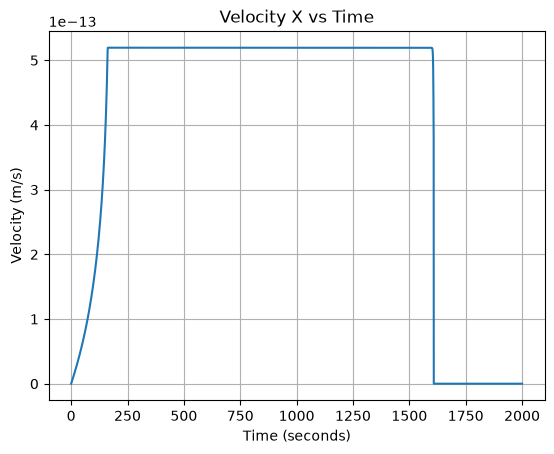

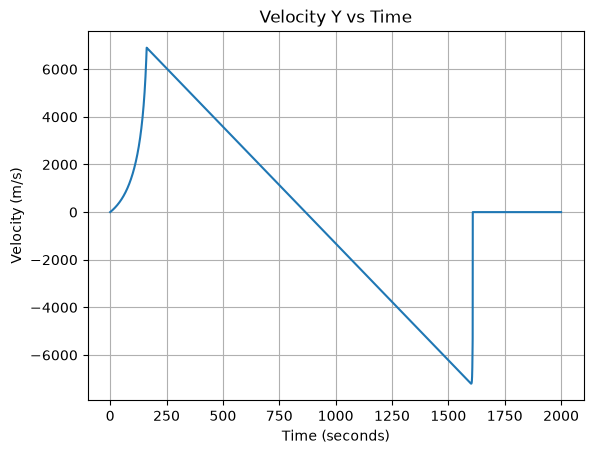

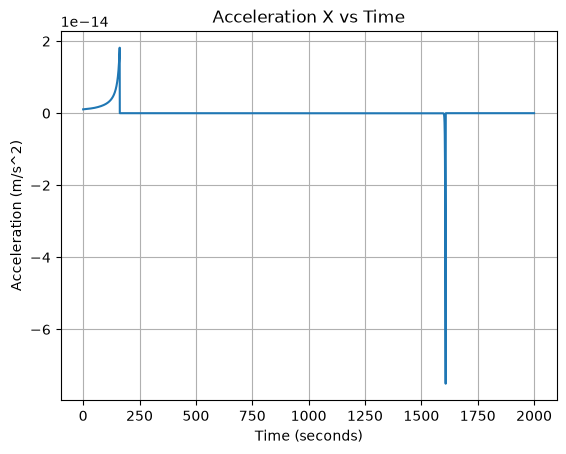

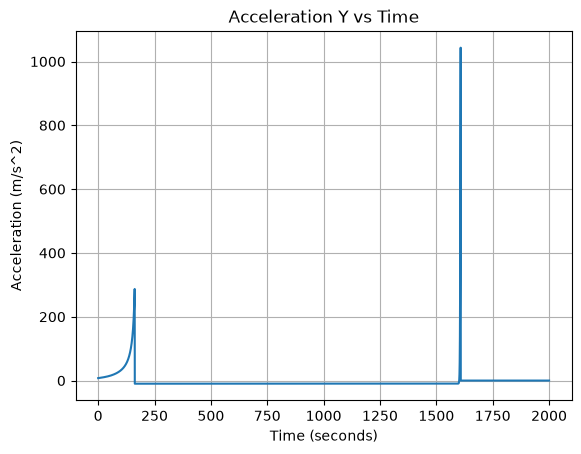

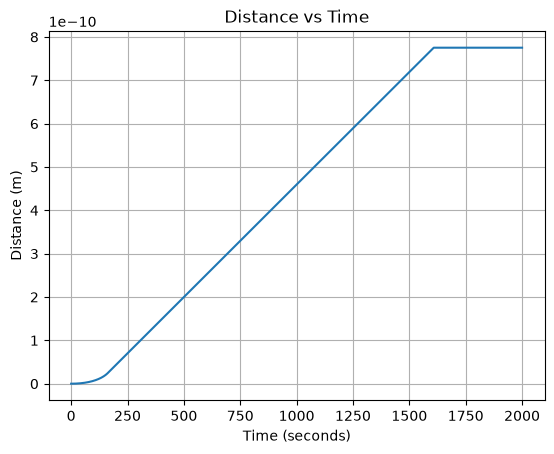

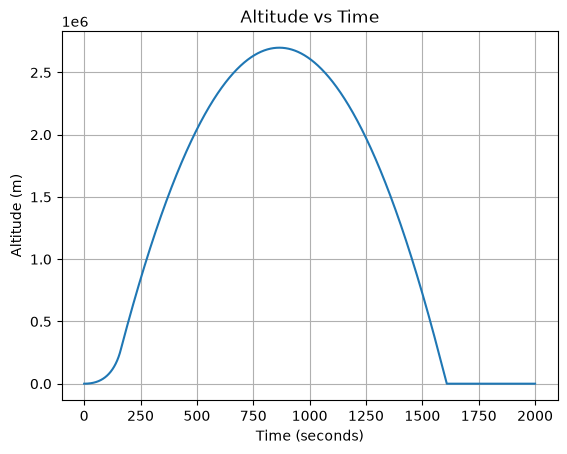

In [4]:
#Logs to store data once simulation is complete
time_log=[]
altitude_log=[]
distance_log=[]
velocity_y_log=[]
velocity_x_log=[]
V_log=[]
accel_x_log = []
accel_y_log = []
fuel_log=[]
mass_log=[]


#simulation
while pos_y >= 0.0 or time == 0.0: #stop simulation when rocket hits ground.
    if time<162:
        THRUST = 7607000
    else:
        THRUST = 0 #Burn time is 162 s, so no more fuel. Rocket is now in coasting phase(no fuel for thrust force)

    V = math.sqrt(vel_y**2+vel_x**2) #total velocity using x and y components
   
    current_air_density = air_density * math.exp(-pos_y / 8500.0) #Equation for thinning air, used to calculate drag throughout the simulation
    drag_force = 0.5 * current_air_density * (V**2) * drag_coefficiant * A #Drag force to oppose the rocket's motion, using air resistance equation
    if V > 1e-5: #starts calculating the moment V is more than 0. Not using V>0 to prevent erros if something divides by 0.
        fdy = drag_force * (vel_y / V) #Direction ratios to get percentage of direction. Allows for angle without complicated trig.
        fdx = drag_force * (vel_x / V) #direction ratios
    else:
        fdy, fdx = 0.0, 0.0 #If the rocket is not moving, there is no drag force

    total_mass = dry_mass + current_fuel #calculating mass of rocket, it decreases as more fuel is used
   
    if current_fuel > 0.0:
        active_thrust = THRUST
        if V>1e-5 and time>60.0: #using time>60 because Falcon 9 blasts staight up during starting phase
            flight_angle = math.atan2(vel_y, vel_x) #splitting into x and y components to make it 2D, this line calculates the angle according to the x and y components
            THRUST_y = THRUST*math.sin(flight_angle) #Splitting thrust using current angle of the trajectory
            THRUST_x = THRUST*math.cos(flight_angle)
        else:
            THRUST_y = THRUST * math.sin(angle_rad)
            THRUST_x = THRUST * math.cos(angle_rad)
           
        current_fuel = current_fuel - (mass_flow_rate * dt) #Calculating the fuel left over using mass flow rate. Models fuel decreasing as the simulation goes on
     
        a_y = ((THRUST_y-fdy)/total_mass)-g #acceleration of rocket (f=ma)
        a_x = ((THRUST_x-fdx)/total_mass) #acceleration in x direction
   
     
    else:
        total_mass = dry_mass + current_fuel
        active_thrust = 0.0 #No more thrust when there is no fuel
        current_fuel = 0.0 
        a_y = (-fdy / total_mass) - g #Acceleration no longer has trust, only forced acting in y-direction are gravity and air resistance
        a_x = -fdx / total_mass #No thrust, just air resistance(drag force)

    vel_y = vel_y + (a_y*dt)  #Calculating velocity at each moment. Based off vf=vi+at
    vel_x = vel_x + (a_x*dt)
   
    if vel_x < 0: #Horizontal velocity should not be negative
        vel_x = 0.0
    pos_y = pos_y + (vel_y * dt) #Updating position 
    pos_x = pos_x + (vel_x * dt)
    V = math.sqrt(vel_y**2 + vel_x**2)
   
    if pos_y < 0.0 and time > 0.0: #Altitude cannot be less than 0, that means rocket is underground
        pos_y = 0.0 #By setting all of these values to 0, it means that the rocket has landed/crashed
        vel_y = 0.0
        vel_x = 0.0
        V = 0.0
        a_x = 0.0
        a_y = 0.0
        
    if time > 2000: #To prevent infinite loop
        break
    if loop_counter % 1000 == 0 or pos_y < 0.0:
        print(f"Time: {time:.1f}s, Velocity: {V:.1f}m/s, Altitude: {pos_y:.1f}m, Horizontal Distance: {pos_x:.1f}m")
   
   
    time = time + dt
    loop_counter += 1  # Increment the step counter
    
    time_log.append(time)
    altitude_log.append(pos_y)
    distance_log.append(pos_x)
    velocity_y_log.append(vel_y)
    velocity_x_log.append(vel_x)
    V_log.append(V)
    accel_x_log.append(a_x)
    accel_y_log.append(a_y)
    fuel_log.append(current_fuel)
    mass_log.append(total_mass)
plt.plot(time_log, velocity_x_log)
plt.title("Velocity X vs Time")
plt.xlabel("Time (seconds)")
plt.ylabel("Velocity (m/s)")
plt.grid(True)
plt.show()

plt.plot(time_log, velocity_y_log)
plt.title("Velocity Y vs Time")
plt.xlabel("Time (seconds)")
plt.ylabel("Velocity (m/s)")
plt.grid(True)
plt.show()

plt.plot(time_log, accel_x_log)
plt.title("Acceleration X vs Time")
plt.xlabel("Time (seconds)")
plt.ylabel("Acceleration (m/s^2)")
plt.grid(True)
plt.show()

plt.plot(time_log, accel_y_log)
plt.title("Acceleration Y vs Time")
plt.xlabel("Time (seconds)")
plt.ylabel("Acceleration (m/s^2)")
plt.grid(True)
plt.show()

plt.plot(time_log, distance_log)
plt.title("Distance vs Time")
plt.xlabel("Time (seconds)")
plt.ylabel("Distance (m)")
plt.grid(True)
plt.show()

plt.plot(time_log, altitude_log)
plt.title("Altitude vs Time")
plt.xlabel("Time (seconds)")
plt.ylabel("Altitude (m)")
plt.grid(True)
plt.show()
 
